# 🎯 Entrenamiento + Evaluación Random Forest — 4 herramientas

Replica el **Modelo 1** del TFG (RF básico, sin RandomizedSearchCV) pero ahora con las 4 herramientas: CIC, Nemea, Tstat y Tshark.

## Flujo

Para cada herramienta:
1. Cargar las 8 clases del `BaseDatos/{clase}/{herramienta}.csv`.
2. Concatenar y añadir columna `Label`.
3. Limpieza mínima: NaN → 0, strings → LabelEncoder.
4. `train_test_split` 80/20 con `random_state=42`.
5. Entrenar `RandomForestClassifier(n_estimators=100)`.
6. Predecir sobre test.
7. Guardar métricas (accuracy, recall, precision, F1) y matriz de confusión.

Al final: **4 matrices de confusión** en un grid 2×2 y **tabla comparativa** entre herramientas.

**Run All y listo, no hay que cambiar nada.**

In [1]:
# ============================================================
# CELDA 0 — IMPORTS Y CONFIGURACIÓN
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import time

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (accuracy_score, recall_score, precision_score,
                              f1_score, confusion_matrix)
import warnings
warnings.filterwarnings('ignore')

BASE_IN = Path('/home/miguel/Escritorio/TFM/TFM_Miguel/BaseDatos')

CLASES = ['BenignTraffic', 'DictionaryBruteForce', 'Recon', 'Mirai',
          'Spoofing', 'DoS', 'DDoS', 'Web']
HERRAMIENTAS = ['CIC', 'Nemea', 'Tstat', 'Tshark']

SEED = 42

print(f'Carpeta de entrada: {BASE_IN}')
print(f'Clases: {len(CLASES)}')
print(f'Herramientas a evaluar: {HERRAMIENTAS}')

Carpeta de entrada: /home/miguel/Escritorio/TFM/TFM_Miguel/BaseDatos
Clases: 8
Herramientas a evaluar: ['CIC', 'Nemea', 'Tstat', 'Tshark']


In [2]:
# ============================================================
# CELDA 1 — FUNCIÓN: cargar y preparar datos de una herramienta
# Versión más segura: limpia SOLO EN MEMORIA, no toca BaseDatos
# ============================================================

def cargar_datos(herramienta, usar_solo_columnas_comunes=True, eliminar_sospechosas=True):
    """
    Carga las 8 clases de una herramienta y devuelve X, y.

    Objetivo:
    - Mantener BaseDatos intacta.
    - Evitar fuga directa: LABEL, attack, class, archivo, pcap, flow_id...
    - Evitar fuga indirecta: columnas que existen en unas clases y en otras no.
    """

    dfs_por_clase = {}
    columnas_por_clase = {}

    # 1) Leer cada clase por separado, SIN concatenar todavía
    for clase in CLASES:
        ruta = BASE_IN / clase / f'{herramienta}.csv'
        df_tmp = pd.read_csv(ruta, low_memory=False)

        dfs_por_clase[clase] = df_tmp
        columnas_por_clase[clase] = list(df_tmp.columns)

    print('\n' + '='*80)
    print(f'CARGA — {herramienta}')
    print('='*80)

    for clase in CLASES:
        df_tmp = dfs_por_clase[clase]
        print(f'{clase:<25} {df_tmp.shape[0]:,} filas x {df_tmp.shape[1]} columnas')

    # 2) Diagnóstico de columnas comunes/no comunes
    conjuntos = [set(columnas_por_clase[clase]) for clase in CLASES]
    columnas_comunes_set = set.intersection(*conjuntos)
    columnas_union_set = set.union(*conjuntos)
    columnas_no_comunes = sorted(columnas_union_set - columnas_comunes_set)

    print(f'\n[{herramienta}] Columnas unión:      {len(columnas_union_set)}')
    print(f'[{herramienta}] Columnas comunes:    {len(columnas_comunes_set)}')
    print(f'[{herramienta}] Columnas no comunes: {len(columnas_no_comunes)}')

    if columnas_no_comunes:
        print(f'\n[{herramienta}] Primeras columnas que NO están en todas las clases:')
        for col in columnas_no_comunes[:50]:
            aparece_en = [clase for clase in CLASES if col in columnas_por_clase[clase]]
            print(f'  - {col}  --> aparece en: {aparece_en}')
        if len(columnas_no_comunes) > 50:
            print(f'  ... y {len(columnas_no_comunes)-50} más')

    # 3) Elegir columnas base ANTES de concatenar
    # Esta es la corrección importante:
    # Si usamos la unión, pandas crea NaN para columnas ausentes en una clase.
    # Al hacer fillna(0), el modelo puede aprender la clase por ausencia/presencia de columnas.
    if usar_solo_columnas_comunes:
        columnas_base = [
            c for c in columnas_por_clase[CLASES[0]]
            if c in columnas_comunes_set
        ]
        print(f'\n[{herramienta}] Usando SOLO columnas comunes: {len(columnas_base)}')
    else:
        columnas_base = sorted(columnas_union_set)
        print(f'\n[{herramienta}] Usando UNIÓN de columnas: {len(columnas_base)}')

    # 4) Eliminar columnas sospechosas de fuga directa
    # OJO: no meto patrones tipo "dos", "web", "mirai", etc. porque pueden ser demasiado agresivos.
    patrones_fuga = [
        # Etiquetas / clases / nombres de ataque
        'label',
        'etiqueta',
        'class',
        'attack',
        'category',
        'subtipo',

        # Origen de fichero/captura
        'archivo',
        'file',
        'pcap',

        # Identificadores de red/dispositivo
        'flow_id',
        'macaddr',
        'mac',
        'src_mac',
        'dst_mac',

        # Dominios / nombres de servicio / DNS / TLS que pueden identificar escenario
        'fqdn',
        'sni',
        'scn',
        'dns_rslv',
        'tls_sesid',
        'npnalpn',
        'alpn',

        # Tiempos absolutos o marcas temporales peligrosas
        'first_abs',
        'req_tm',
        'res_tm',
        'handshaket',
        'appdatat',
    ]

    columnas_id_exactas = {
        'id',
        'ID',
        'Flow ID',
        'FLOW_ID',
        'flow_id',
        'uint64 FLOW_ID',
    }

    columnas_temporales_peligrosas_exactas = {
        # Nemea: tiempos absolutos de burst
        'time* DBI_BRST_TIME_START',
        'time* DBI_BRST_TIME_STOP',
        'time* SBI_BRST_TIME_START',
        'time* SBI_BRST_TIME_STOP',

        # Tstat: timestamps absolutos
        'last',
        'req_tm',
        'res_tm',
        's_first_abs',
        'c_first',
        's_first',
        'c_last',
        's_last',
        'c_first_ack',
        's_first_ack',
        'c_last_handshakeT',
        's_last_handshakeT',
        'c_appdataT',
        's_appdataT',
    }
    

    columnas_sospechosas = []

    if eliminar_sospechosas:
        for col in columnas_base:
            col_lower = col.lower()

            es_sospechosa_por_patron = any(p in col_lower for p in patrones_fuga)

            es_id = (
                col in columnas_id_exactas
                or col_lower in columnas_id_exactas
            )

            es_temporal_peligrosa = (
                col in columnas_temporales_peligrosas_exactas
                or col_lower in columnas_temporales_peligrosas_exactas
                or col_lower.startswith('time_ppi_pkt_times_')
            )

            if es_sospechosa_por_patron or es_id or es_temporal_peligrosa:
                columnas_sospechosas.append(col)

    if columnas_sospechosas:
        print(f'\n[{herramienta}] Columnas eliminadas por posible fuga directa:')
        for c in columnas_sospechosas:
            print(f'  - {c}')

    columnas_finales = [c for c in columnas_base if c not in columnas_sospechosas]

    print(f'\n[{herramienta}] Columnas finales antes de concatenar: {len(columnas_finales)}')

    # 5) Construir dataset final
    dfs = []

    for clase in CLASES:
        if usar_solo_columnas_comunes:
            df_tmp = dfs_por_clase[clase][columnas_finales].copy()
        else:
            # Modo diagnóstico: reindex mete NaN donde una columna no existía.
            # Sirve para comparar, pero NO es el modo recomendado.
            df_tmp = dfs_por_clase[clase].reindex(columns=columnas_finales).copy()

        # Esta es la etiqueta buena. Solo se usará como y.
        df_tmp['Label_Modelo'] = clase
        dfs.append(df_tmp)

    df = pd.concat(dfs, ignore_index=True, sort=False)

    y = df['Label_Modelo']
    X = df.drop(columns=['Label_Modelo'])

    # 6) Codificar columnas object
    cols_obj = X.select_dtypes(include=['object']).columns.tolist()

    if cols_obj:
        print(f'\n[{herramienta}] Columnas object codificadas con LabelEncoder:')
        for c in cols_obj:
            print(f'  - {c}')

    for col in cols_obj:
        X[col] = X[col].fillna('__missing__').astype(str)
        X[col] = LabelEncoder().fit_transform(X[col])

    # 7) Infinitos/NaN
    X = X.replace([np.inf, -np.inf], np.nan)

    n_nan = int(X.isna().sum().sum())
    if n_nan > 0:
        print(f'\n[{herramienta}] NaN antes de fillna: {n_nan:,}')
        print('Esto solo debería pasar si usas unión de columnas o si el CSV ya tenía NaN.')

    X = X.fillna(0)

    # 8) Eliminar constantes DESPUÉS de juntar todas las clases
    # Así no generamos esquemas distintos por clase.
    cols_constantes = [c for c in X.columns if X[c].nunique(dropna=False) <= 1]

    if cols_constantes:
        print(f'\n[{herramienta}] Columnas constantes eliminadas tras concatenar:')
        for c in cols_constantes:
            print(f'  - {c}')
        X = X.drop(columns=cols_constantes)

    print(f'\n[{herramienta}] Shape final X: {X.shape}')
    print(f'[{herramienta}] Distribución y:')
    print(y.value_counts())

    return X, y


In [3]:
# ============================================================
# CELDA EXTRA — DIAGNÓSTICO DE COLUMNAS SOSPECHOSAS
# ============================================================

for herr in HERRAMIENTAS:
    print('\n' + '='*80)
    print(f'DIAGNÓSTICO PREVIO — {herr}')
    print('='*80)

    X_test_diag, y_test_diag = cargar_datos(herr, eliminar_sospechosas=False)

    print(f'\n[{herr}] Shape SIN eliminar sospechosas: {X_test_diag.shape}')

    del X_test_diag, y_test_diag
    import gc
    gc.collect()


DIAGNÓSTICO PREVIO — CIC

CARGA — CIC
BenignTraffic             3,481 filas x 71 columnas
DictionaryBruteForce      3,481 filas x 71 columnas
Recon                     3,481 filas x 71 columnas
Mirai                     3,481 filas x 71 columnas
Spoofing                  3,481 filas x 71 columnas
DoS                       3,481 filas x 71 columnas
DDoS                      3,481 filas x 71 columnas
Web                       3,481 filas x 71 columnas

[CIC] Columnas unión:      71
[CIC] Columnas comunes:    71
[CIC] Columnas no comunes: 0

[CIC] Usando SOLO columnas comunes: 71

[CIC] Columnas finales antes de concatenar: 71

[CIC] Columnas object codificadas con LabelEncoder:
  - Label

[CIC] NaN antes de fillna: 2
Esto solo debería pasar si usas unión de columnas o si el CSV ya tenía NaN.

[CIC] Columnas constantes eliminadas tras concatenar:
  - URG Flag Count

[CIC] Shape final X: (27848, 70)
[CIC] Distribución y:
Label_Modelo
BenignTraffic           3481
DictionaryBruteForce    34

In [4]:
for herr in HERRAMIENTAS:
    print('\n' + '='*80)
    print(f'COMPROBACIÓN DE COLUMNAS FINALES — {herr}')
    print('='*80)

    X, y = cargar_datos(
        herr,
        usar_solo_columnas_comunes=True,
        eliminar_sospechosas=True
    )

    columnas_prohibidas = [
        'label', 'etiqueta', 'category', 'attack', 'class',
        'mac', 'fqdn', 'sni', 'scn', 'dns_rslv',
        'flow_id', 'pcap', 'archivo', 'file'
    ]

    malas = [
        c for c in X.columns
        if any(p in c.lower() for p in columnas_prohibidas)
    ]

    tiempos_malos = [
        c for c in X.columns
        if c.lower().startswith('time_ppi_pkt_times_')
        or c in ['last', 'req_tm', 'res_tm']
    ]

    print(f'Columnas finales: {X.shape[1]}')

    if malas:
        print('⚠ Todavía quedan columnas sospechosas:')
        for c in malas:
            print('  -', c)
    else:
        print('✓ No quedan columnas sospechosas por nombre.')

    if tiempos_malos:
        print('⚠ Todavía quedan columnas temporales peligrosas:')
        for c in tiempos_malos:
            print('  -', c)
    else:
        print('✓ No quedan timestamps absolutos peligrosos.')

    del X, y


COMPROBACIÓN DE COLUMNAS FINALES — CIC

CARGA — CIC
BenignTraffic             3,481 filas x 71 columnas
DictionaryBruteForce      3,481 filas x 71 columnas
Recon                     3,481 filas x 71 columnas
Mirai                     3,481 filas x 71 columnas
Spoofing                  3,481 filas x 71 columnas
DoS                       3,481 filas x 71 columnas
DDoS                      3,481 filas x 71 columnas
Web                       3,481 filas x 71 columnas

[CIC] Columnas unión:      71
[CIC] Columnas comunes:    71
[CIC] Columnas no comunes: 0

[CIC] Usando SOLO columnas comunes: 71

[CIC] Columnas eliminadas por posible fuga directa:
  - Label

[CIC] Columnas finales antes de concatenar: 70

[CIC] NaN antes de fillna: 2
Esto solo debería pasar si usas unión de columnas o si el CSV ya tenía NaN.

[CIC] Columnas constantes eliminadas tras concatenar:
  - URG Flag Count

[CIC] Shape final X: (27848, 69)
[CIC] Distribución y:
Label_Modelo
BenignTraffic           3481
DictionaryBr

In [5]:
# ============================================================
# CELDA 2 — FUNCIÓN: entrenar Random Forest y evaluar
# Con importancia de variables
# ============================================================

def entrenar_y_evaluar(X, y, herramienta):
    """Train/test split + RF + métricas + matriz + importancia de features."""

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=SEED,
        stratify=y
    )

    rf = RandomForestClassifier(
        n_estimators=100,
        random_state=SEED,
        n_jobs=-1
    )

    t0 = time.time()
    rf.fit(X_train, y_train)
    t_train = time.time() - t0

    t0 = time.time()
    y_pred = rf.predict(X_test)
    t_pred = time.time() - t0

    metricas = {
        'Accuracy':  accuracy_score(y_test, y_pred),
        'Recall':    recall_score(y_test, y_pred, average='macro'),
        'Precision': precision_score(y_test, y_pred, average='macro'),
        'F1-score':  f1_score(y_test, y_pred, average='macro'),
        'Tiempo train (s)': t_train,
        'Tiempo pred (s)':  t_pred,
        'N features':       X.shape[1],
    }

    cm = confusion_matrix(y_test, y_pred, labels=CLASES)

    importancias = pd.DataFrame({
        'feature': X.columns,
        'importance': rf.feature_importances_
    }).sort_values('importance', ascending=False)

    print(f'\n[{herramienta}] Top 25 features más importantes:')
    print(importancias.head(25).to_string(index=False))

    return metricas, cm, importancias

In [6]:
# ============================================================
# CELDA 3 — BUCLE PRINCIPAL: las 4 herramientas
# ============================================================

resultados = {}
matrices = {}
importancias_por_herramienta = {}

for herr in HERRAMIENTAS:
    print(f'\n{"="*80}')
    print(f'  PROCESANDO {herr}')
    print(f'{"="*80}')

    t0 = time.time()

    # MODO RECOMENDADO:
    # - solo columnas comunes a todas las clases
    # - eliminar columnas sospechosas
    X, y = cargar_datos(
        herr,
        usar_solo_columnas_comunes=True,
        eliminar_sospechosas=True
    )

    print(f'\n[{herr}] Shape usado para entrenamiento: {X.shape}')
    print(f'[{herr}] Features: {X.shape[1]}')
    print(f'[{herr}] Filas: {X.shape[0]:,}')

    metricas, cm, importancias = entrenar_y_evaluar(X, y, herr)

    t_total = time.time() - t0

    resultados[herr] = metricas
    matrices[herr] = cm
    importancias_por_herramienta[herr] = importancias

    print(f'\n[{herr}] RESULTADO FINAL')
    print(f'  Accuracy : {metricas["Accuracy"]:.4f}')
    print(f'  F1-score : {metricas["F1-score"]:.4f}')
    print(f'  N features: {metricas["N features"]}')
    print(f'  Tiempo total: {t_total:.1f}s')

    del X, y
    import gc
    gc.collect()



  PROCESANDO CIC

CARGA — CIC
BenignTraffic             3,481 filas x 71 columnas
DictionaryBruteForce      3,481 filas x 71 columnas
Recon                     3,481 filas x 71 columnas
Mirai                     3,481 filas x 71 columnas
Spoofing                  3,481 filas x 71 columnas
DoS                       3,481 filas x 71 columnas
DDoS                      3,481 filas x 71 columnas
Web                       3,481 filas x 71 columnas

[CIC] Columnas unión:      71
[CIC] Columnas comunes:    71
[CIC] Columnas no comunes: 0

[CIC] Usando SOLO columnas comunes: 71

[CIC] Columnas eliminadas por posible fuga directa:
  - Label

[CIC] Columnas finales antes de concatenar: 70

[CIC] NaN antes de fillna: 2
Esto solo debería pasar si usas unión de columnas o si el CSV ya tenía NaN.

[CIC] Columnas constantes eliminadas tras concatenar:
  - URG Flag Count

[CIC] Shape final X: (27848, 69)
[CIC] Distribución y:
Label_Modelo
BenignTraffic           3481
DictionaryBruteForce    3481
Recon

In [7]:
# ============================================================
# CELDA 4 — TABLA COMPARATIVA DE MÉTRICAS
# ============================================================

df_resumen = pd.DataFrame(resultados).T
df_resumen = df_resumen[['Accuracy', 'Recall', 'Precision', 'F1-score',
                           'N features', 'Tiempo train (s)', 'Tiempo pred (s)']]

# Formato
df_show = df_resumen.copy()
for col in ['Accuracy', 'Recall', 'Precision', 'F1-score']:
    df_show[col] = df_show[col].apply(lambda x: f'{x:.4f}')
for col in ['Tiempo train (s)', 'Tiempo pred (s)']:
    df_show[col] = df_show[col].apply(lambda x: f'{x:.2f}')
df_show['N features'] = df_show['N features'].astype(int)

print('='*70)
print('  COMPARATIVA — Random Forest básico (Modelo 1 del TFG) × 4 herramientas')
print('='*70)
print(df_show.to_string())
print()

# Mejor herramienta según F1
mejor = df_resumen['F1-score'].idxmax()
print(f'  → Mejor F1-score: {mejor} ({df_resumen.loc[mejor, "F1-score"]:.4f})')

  COMPARATIVA — Random Forest básico (Modelo 1 del TFG) × 4 herramientas
       Accuracy  Recall Precision F1-score  N features Tiempo train (s) Tiempo pred (s)
CIC      0.7106  0.7106    0.7097   0.7099          69             2.77            0.11
Nemea    0.5980  0.5980    0.6243   0.5829         148             1.81            0.13
Tstat    0.6346  0.6346    0.6665   0.6311          96             1.57            0.13
Tshark   0.7431  0.7431    0.7446   0.7434          50             2.39            0.13

  → Mejor F1-score: Tshark (0.7434)


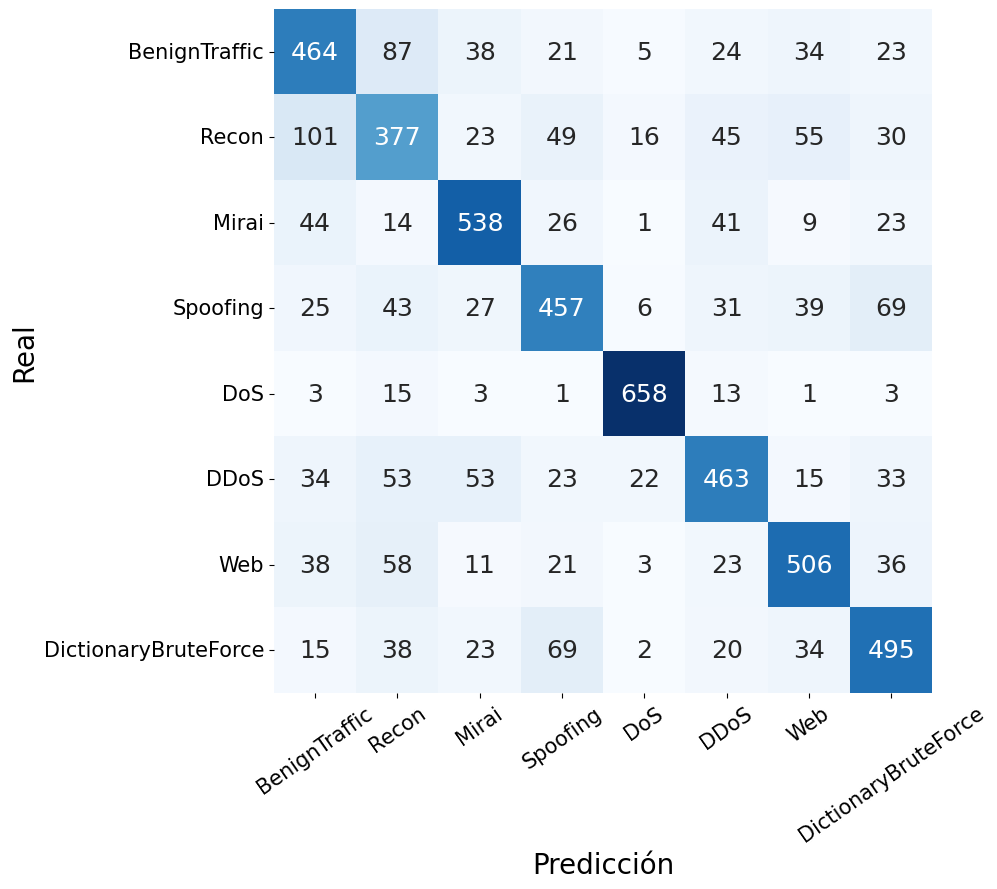

✓ Guardado: /home/miguel/Escritorio/TFM/TFM_Miguel/Figuras/cm_rf_basico_CIC.pdf


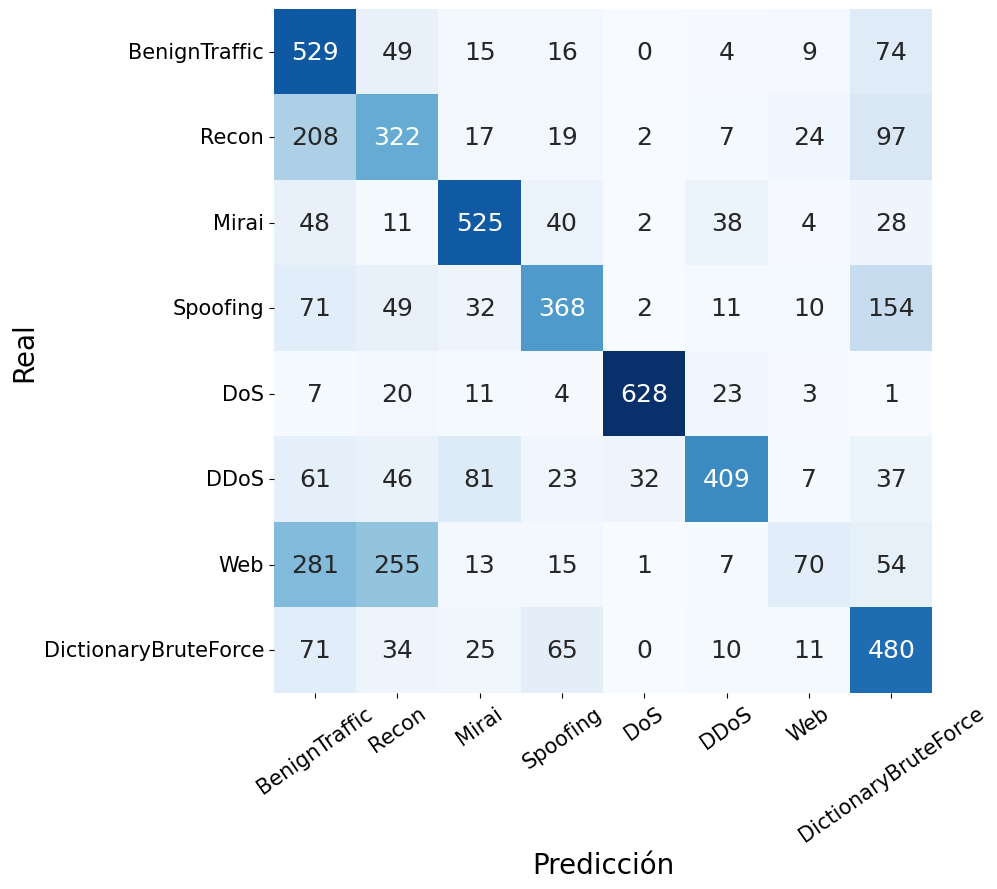

✓ Guardado: /home/miguel/Escritorio/TFM/TFM_Miguel/Figuras/cm_rf_basico_Nemea.pdf


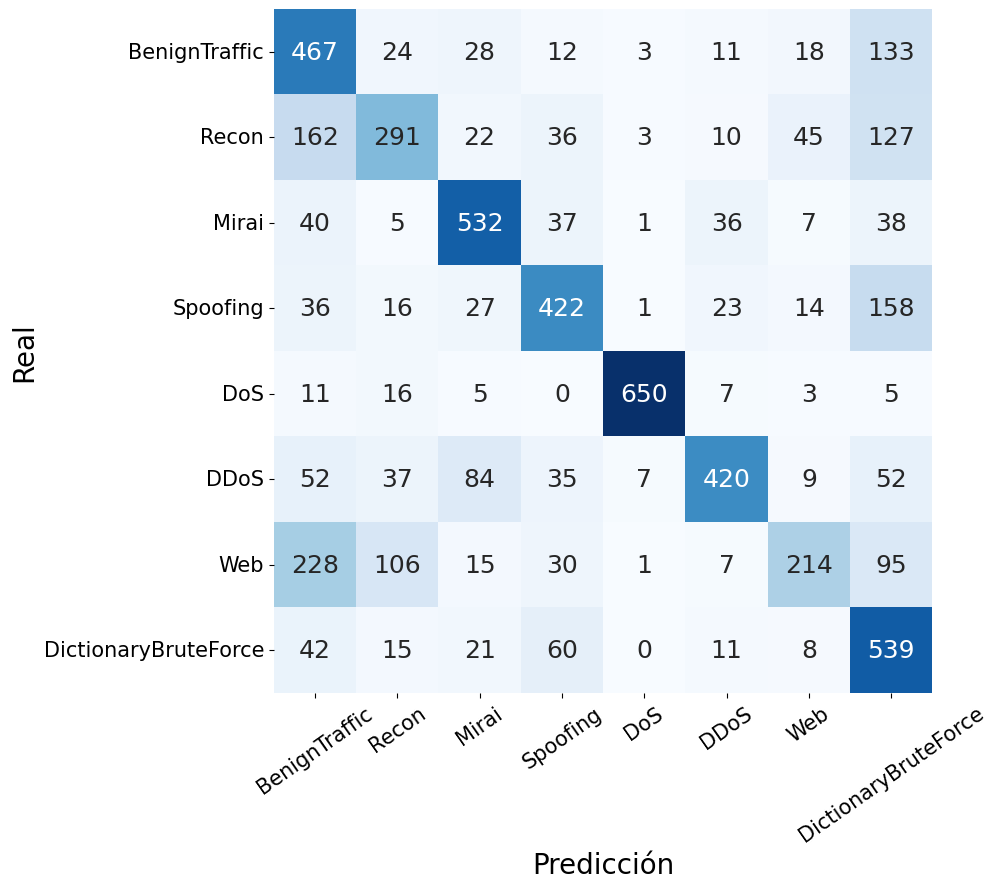

✓ Guardado: /home/miguel/Escritorio/TFM/TFM_Miguel/Figuras/cm_rf_basico_Tstat.pdf


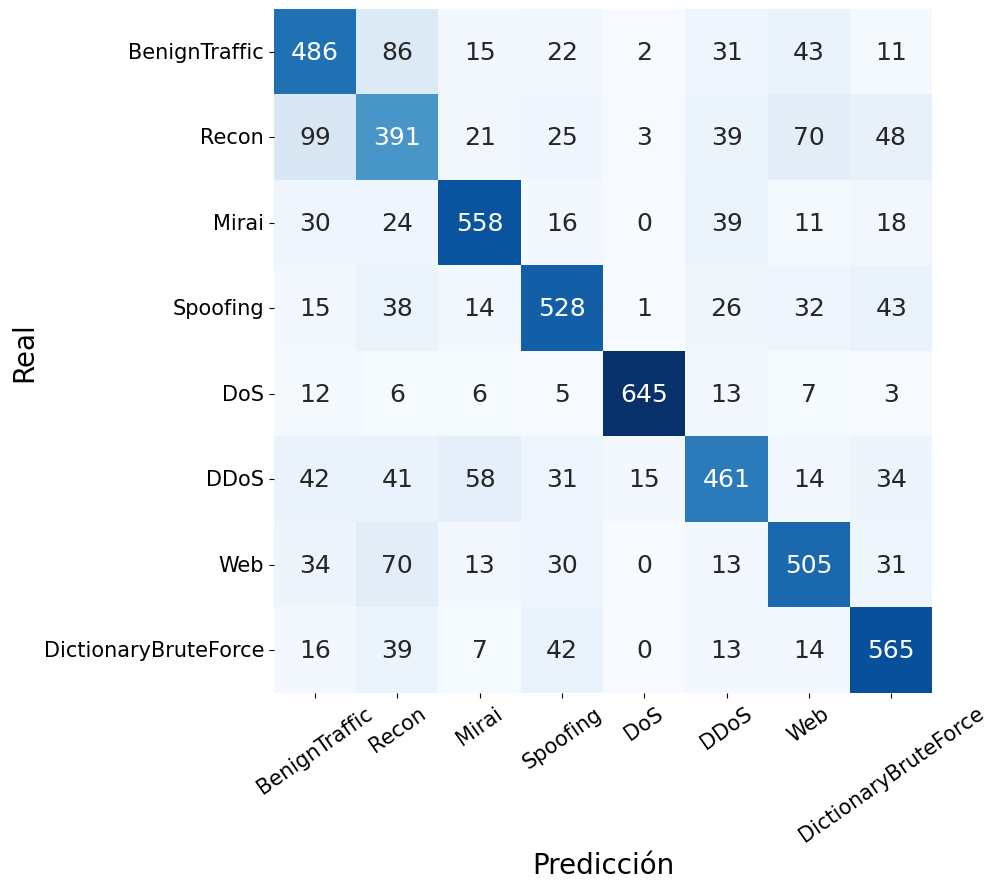

✓ Guardado: /home/miguel/Escritorio/TFM/TFM_Miguel/Figuras/cm_rf_basico_Tshark.pdf


In [8]:
# ============================================================
# CELDA 5 — MATRICES DE CONFUSIÓN (4 PDF separados, uno por herramienta)
# ============================================================

RUTA_FIGURAS = Path('/home/miguel/Escritorio/TFM/TFM_Miguel/Figuras')
RUTA_FIGURAS.mkdir(parents=True, exist_ok=True)

# Orden solo para el dibujo: DictionaryBruteForce pasa al final (esquina inferior derecha)
ORDEN_FIGURA = ['BenignTraffic', 'Recon', 'Mirai', 'Spoofing',
                'DoS', 'DDoS', 'Web', 'DictionaryBruteForce']
perm = [CLASES.index(c) for c in ORDEN_FIGURA]

for herr in HERRAMIENTAS:
    cm = matrices[herr]
    cm_ordenada = cm[perm][:, perm]

    fig, ax = plt.subplots(figsize=(10, 9))
    sns.heatmap(cm_ordenada, annot=True, fmt='d', cmap='Blues',
                xticklabels=ORDEN_FIGURA, yticklabels=ORDEN_FIGURA,
                cbar=False, ax=ax, annot_kws={'size': 18})

    ax.set_xlabel('Predicción', fontsize=20)
    ax.set_ylabel('Real', fontsize=20)
    ax.tick_params(axis='x', rotation=35, labelsize=15)
    ax.tick_params(axis='y', rotation=0,  labelsize=15)

    plt.tight_layout()

    ruta_pdf = RUTA_FIGURAS / f'cm_rf_basico_{herr}.pdf'
    fig.savefig(ruta_pdf, format='pdf', bbox_inches='tight')
    plt.show()
    plt.close(fig)
    print(f'✓ Guardado: {ruta_pdf}')

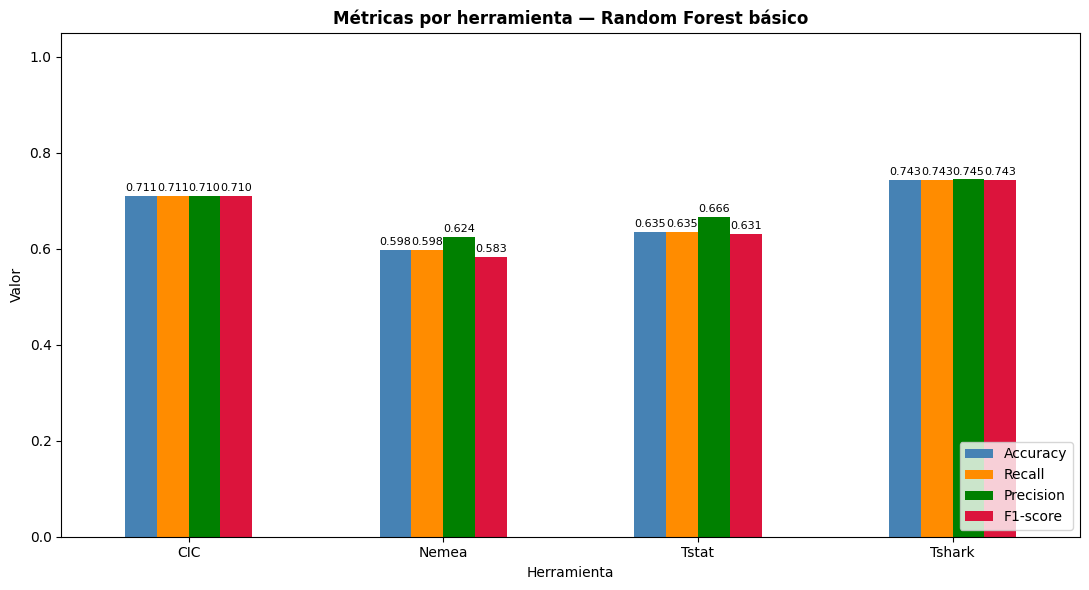

In [9]:
# ============================================================
# CELDA 6 — GRÁFICO COMPARATIVO DE MÉTRICAS
# ============================================================

metricas_plot = df_resumen[['Accuracy', 'Recall', 'Precision', 'F1-score']]

fig, ax = plt.subplots(figsize=(11, 6))
metricas_plot.plot.bar(ax=ax, color=['steelblue', 'darkorange', 'green', 'crimson'])
ax.set_title('Métricas por herramienta — Random Forest básico',
             fontsize=12, fontweight='bold')
ax.set_ylabel('Valor')
ax.set_xlabel('Herramienta')
ax.set_ylim(0, 1.05)
ax.legend(loc='lower right')
ax.set_xticklabels(HERRAMIENTAS, rotation=0)
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', fontsize=8, padding=2)
plt.tight_layout()
plt.show()

In [10]:
# ============================================================
# CELDA EXTRA — TEST DE ETIQUETAS ALEATORIAS
# Con 8 clases balanceadas debería dar cerca de 0.125.
# Si da muy alto, queda fuga fuerte.
# ============================================================

for herr in HERRAMIENTAS:
    print('\n' + '='*80)
    print(f'TEST Y ALEATORIA — {herr}')
    print('='*80)

    X, y = cargar_datos(
        herr,
        usar_solo_columnas_comunes=True,
        eliminar_sospechosas=True
    )

    y_random = y.sample(frac=1, random_state=SEED).reset_index(drop=True)
    X_random = X.reset_index(drop=True)

    metricas_random, _, _ = entrenar_y_evaluar(X_random, y_random, herr + '_Y_RANDOM')

    print(f'\n[{herr}] Accuracy con etiquetas aleatorias: {metricas_random["Accuracy"]:.4f}')
    print(f'[{herr}] F1 con etiquetas aleatorias: {metricas_random["F1-score"]:.4f}')

    del X, y, X_random, y_random
    import gc
    gc.collect()



TEST Y ALEATORIA — CIC

CARGA — CIC
BenignTraffic             3,481 filas x 71 columnas
DictionaryBruteForce      3,481 filas x 71 columnas
Recon                     3,481 filas x 71 columnas
Mirai                     3,481 filas x 71 columnas
Spoofing                  3,481 filas x 71 columnas
DoS                       3,481 filas x 71 columnas
DDoS                      3,481 filas x 71 columnas
Web                       3,481 filas x 71 columnas

[CIC] Columnas unión:      71
[CIC] Columnas comunes:    71
[CIC] Columnas no comunes: 0

[CIC] Usando SOLO columnas comunes: 71

[CIC] Columnas eliminadas por posible fuga directa:
  - Label

[CIC] Columnas finales antes de concatenar: 70

[CIC] NaN antes de fillna: 2
Esto solo debería pasar si usas unión de columnas o si el CSV ya tenía NaN.

[CIC] Columnas constantes eliminadas tras concatenar:
  - URG Flag Count

[CIC] Shape final X: (27848, 69)
[CIC] Distribución y:
Label_Modelo
BenignTraffic           3481
DictionaryBruteForce    3481

In [11]:
# CELDA THROUGHPUT — RF
import numpy as np

N_TEST = 5570  # 20% de 27848

BYTES_MEDIO_FLUJO = {
    'CIC':    116,
    'Nemea':  247,
    'Tstat':  114,
    'Tshark': 206
}

print('\n' + '='*70)
print('  THROUGHPUT — RF')
print('='*70)
print(f'  {"Herramienta":10s}  {"µs/muestra":12s}  {"Flujos/s":12s}  {"Throughput (Mbps)":18s}')
print(f'  {"-"*10}  {"-"*12}  {"-"*12}  {"-"*18}')

for herr in HERRAMIENTAS:
    t_pred_s = df_resumen.loc[herr, 'Tiempo pred (s)']
    us_muestra = (t_pred_s / N_TEST) * 1e6
    flujos_s = 1e6 / us_muestra
    bytes_medio = BYTES_MEDIO_FLUJO[herr]
    throughput_mbps = (flujos_s * bytes_medio * 8) / 1e6
    print(f'  {herr:10s}  {us_muestra:12.1f}  {flujos_s:12.0f}  {throughput_mbps:18.1f}')


  THROUGHPUT — RF
  Herramienta  µs/muestra    Flujos/s      Throughput (Mbps) 
  ----------  ------------  ------------  ------------------
  CIC                 20.1         49717                46.1
  Nemea               23.7         42258                83.5
  Tstat               23.0         43425                39.6
  Tshark              22.6         44163                72.8


In [12]:
import pandas as pd
from pathlib import Path

RUTA_BASE = Path('/home/miguel/Escritorio/TFM/TFM_Miguel/BaseDatos')
CLASES = ['BenignTraffic', 'DictionaryBruteForce', 'Recon', 'Mirai', 
          'Spoofing', 'DoS', 'DDoS', 'Web']

# Columnas de bytes por herramienta
cols_bytes = {
    'CIC':    'Total Length of Fwd Packet',  # o Flow Bytes/s * Flow Duration
    'Nemea':  'uint64 BYTES',
    'Tstat':  'c_bytes_all',
    'Tshark': None  # Tshark no tiene bytes totales directamente
}

for herramienta, col in cols_bytes.items():
    if col is None:
        print(f'{herramienta}: sin columna de bytes directa')
        continue
    dfs = []
    for clase in CLASES:
        ruta = RUTA_BASE / clase / f'{herramienta}.csv'
        if ruta.exists():
            df = pd.read_csv(ruta, usecols=[col], low_memory=False)
            dfs.append(df)
    if dfs:
        total = pd.concat(dfs)
        print(f'{herramienta} — media bytes/flujo: {total[col].mean():.0f}  '
              f'mediana: {total[col].median():.0f}')

CIC — media bytes/flujo: 92103  mediana: 48
Nemea — media bytes/flujo: 161870  mediana: 101
Tstat — media bytes/flujo: 33711  mediana: 51
Tshark: sin columna de bytes directa


In [13]:
import pandas as pd
from pathlib import Path
import numpy as np

RUTA_BASE = Path('/home/miguel/Escritorio/TFM/TFM_Miguel/BaseDatos')
CLASES = ['BenignTraffic', 'DictionaryBruteForce', 'Recon', 'Mirai', 
          'Spoofing', 'DoS', 'DDoS', 'Web']

# Tshark: payload.mean * número medio de paquetes del flujo
# Aproximación: bytes_flujo ≈ payload.mean * prate * flow_duration_s
dfs = []
for clase in CLASES:
    ruta = RUTA_BASE / clase / 'Tshark.csv'
    if ruta.exists():
        df = pd.read_csv(ruta, usecols=['payload.mean', 'flow_duration_s', 'prate'], 
                         low_memory=False)
        dfs.append(df)

if dfs:
    total = pd.concat(dfs)
    total['bytes_aprox'] = total['payload.mean'] * total['prate'] * total['flow_duration_s']
    print(f'Tshark — media bytes/flujo: {total["bytes_aprox"].mean():.0f}  '
          f'mediana: {total["bytes_aprox"].median():.0f}')

Tshark — media bytes/flujo: 36566  mediana: 206


In [14]:
import pandas as pd
from pathlib import Path

RUTA_BASE = Path('/home/miguel/Escritorio/TFM/TFM_Miguel/BaseDatos')
CLASES = ['BenignTraffic', 'DictionaryBruteForce', 'Recon', 'Mirai',
          'Spoofing', 'DoS', 'DDoS', 'Web']

# Ahora sumando ambas direcciones para que sea un total real del flujo
cols_bytes = {
    'CIC':    ['Total Length of Fwd Packet', 'Total Length of Bwd Packet'],
    'Nemea':  ['uint64 BYTES', 'uint64 BYTES_REV'],
    'Tstat':  ['c_bytes_all', 's_bytes_all'],
}

for herramienta, cols in cols_bytes.items():
    dfs = []
    for clase in CLASES:
        ruta = RUTA_BASE / clase / f'{herramienta}.csv'
        if ruta.exists():
            df = pd.read_csv(ruta, usecols=cols, low_memory=False)
            df['bytes_total'] = df[cols[0]] + df[cols[1]]
            dfs.append(df[['bytes_total']])
    if dfs:
        total = pd.concat(dfs)
        print(f'{herramienta} — media bytes/flujo: {total["bytes_total"].mean():.0f}  '
              f'mediana: {total["bytes_total"].median():.0f}')

CIC — media bytes/flujo: 94429  mediana: 116
Nemea — media bytes/flujo: 164028  mediana: 247
Tstat — media bytes/flujo: 37455  mediana: 114


In [15]:
# CELDA — CONSTRUCCIÓN DE datos_bytes (con bytes totales, ambas direcciones)
import pandas as pd
from pathlib import Path

RUTA_BASE = Path('/home/miguel/Escritorio/TFM/TFM_Miguel/BaseDatos')
CLASES = ['BenignTraffic', 'DictionaryBruteForce', 'Recon', 'Mirai',
          'Spoofing', 'DoS', 'DDoS', 'Web']

cols_bytes = {
    'CIC':    ['Total Length of Fwd Packet', 'Total Length of Bwd Packet'],
    'Nemea':  ['uint64 BYTES', 'uint64 BYTES_REV'],
    'Tstat':  ['c_bytes_all', 's_bytes_all'],
}

datos_bytes = {}

for herramienta, cols in cols_bytes.items():
    dfs = []
    for clase in CLASES:
        ruta = RUTA_BASE / clase / f'{herramienta}.csv'
        if ruta.exists():
            df = pd.read_csv(ruta, usecols=cols, low_memory=False)
            df['bytes_total'] = df[cols[0]] + df[cols[1]]
            dfs.append(df[['bytes_total']])
    if dfs:
        datos_bytes[herramienta] = pd.concat(dfs)['bytes_total']

# Tshark: se mantiene igual que antes, ya representaba el flujo completo
dfs = []
for clase in CLASES:
    ruta = RUTA_BASE / clase / 'Tshark.csv'
    if ruta.exists():
        df = pd.read_csv(ruta, usecols=['payload.mean', 'flow_duration_s', 'prate'],
                          low_memory=False)
        dfs.append(df)
if dfs:
    total = pd.concat(dfs)
    datos_bytes['Tshark'] = total['payload.mean'] * total['prate'] * total['flow_duration_s']

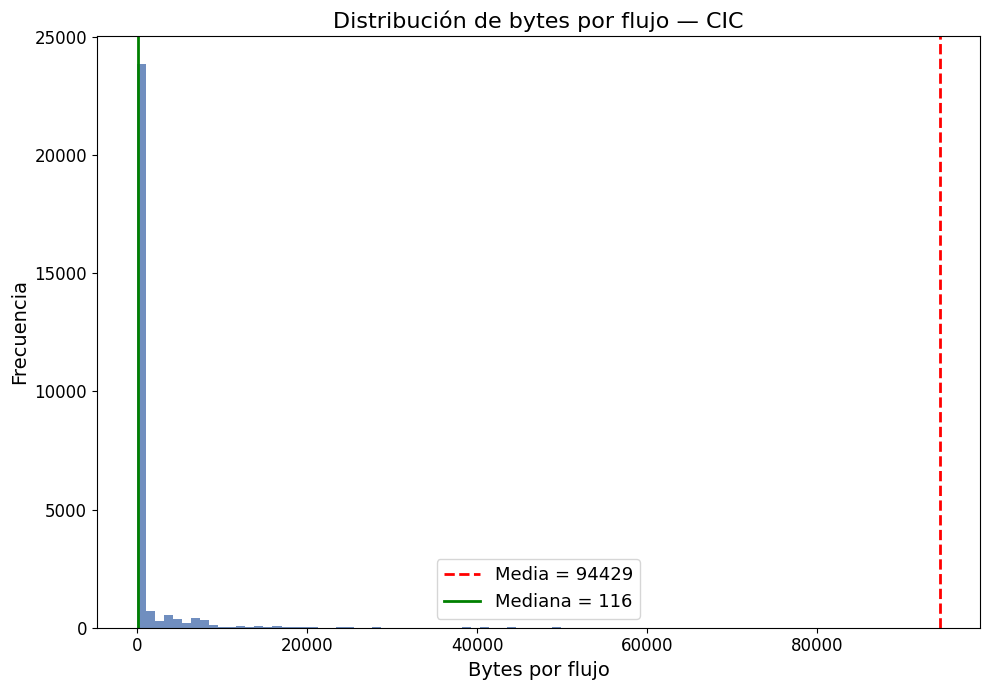

✓ Guardado: /home/miguel/Escritorio/TFM/TFM_Miguel/Figuras/distribucion_bytes_CIC.pdf


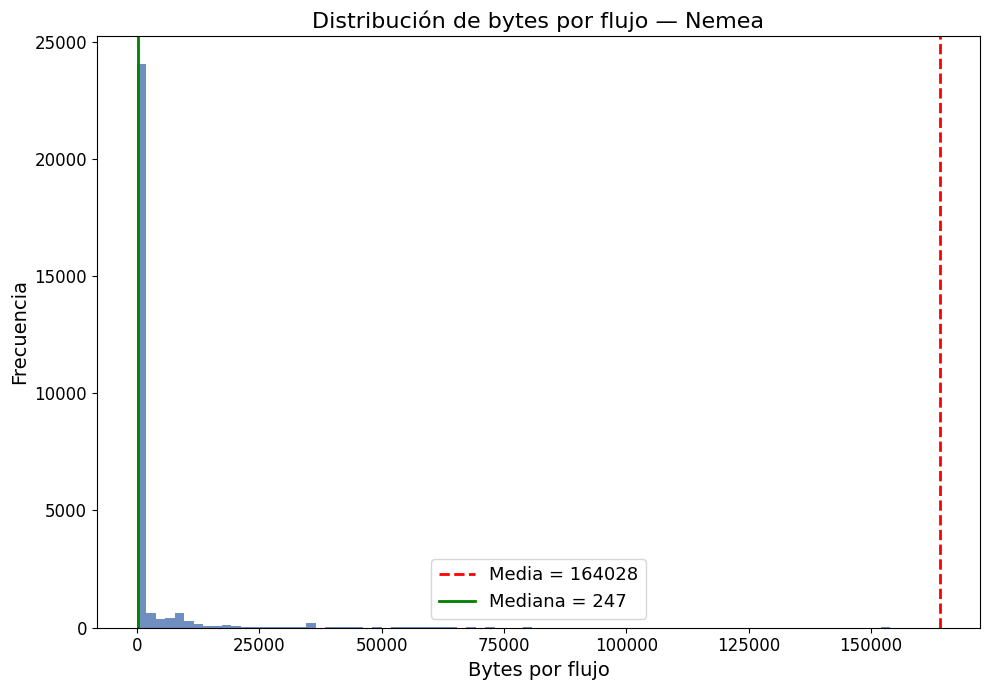

✓ Guardado: /home/miguel/Escritorio/TFM/TFM_Miguel/Figuras/distribucion_bytes_Nemea.pdf


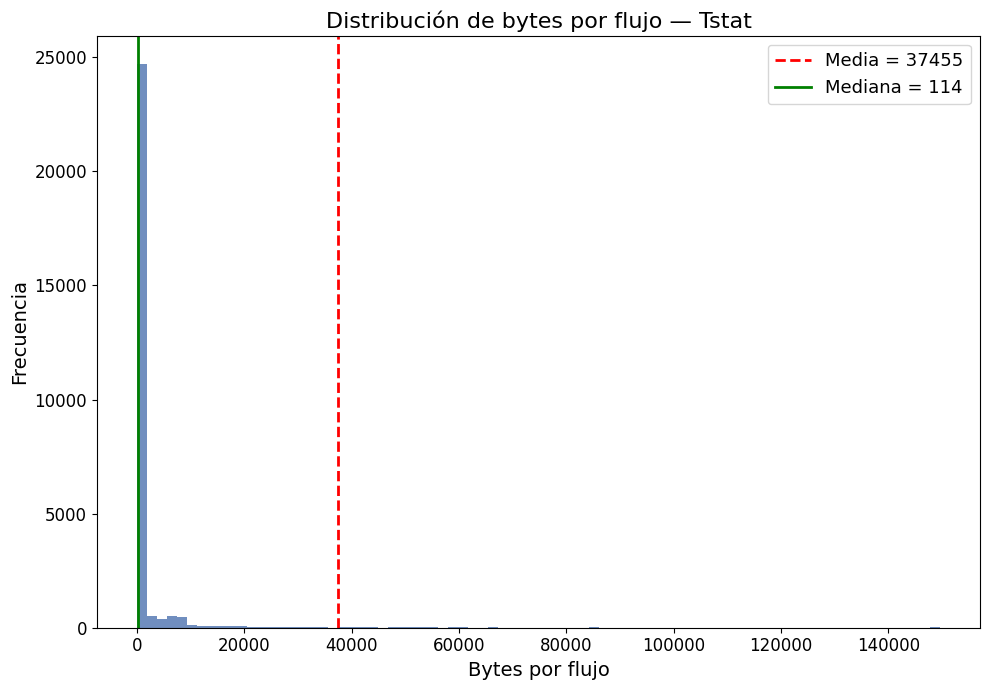

✓ Guardado: /home/miguel/Escritorio/TFM/TFM_Miguel/Figuras/distribucion_bytes_Tstat.pdf


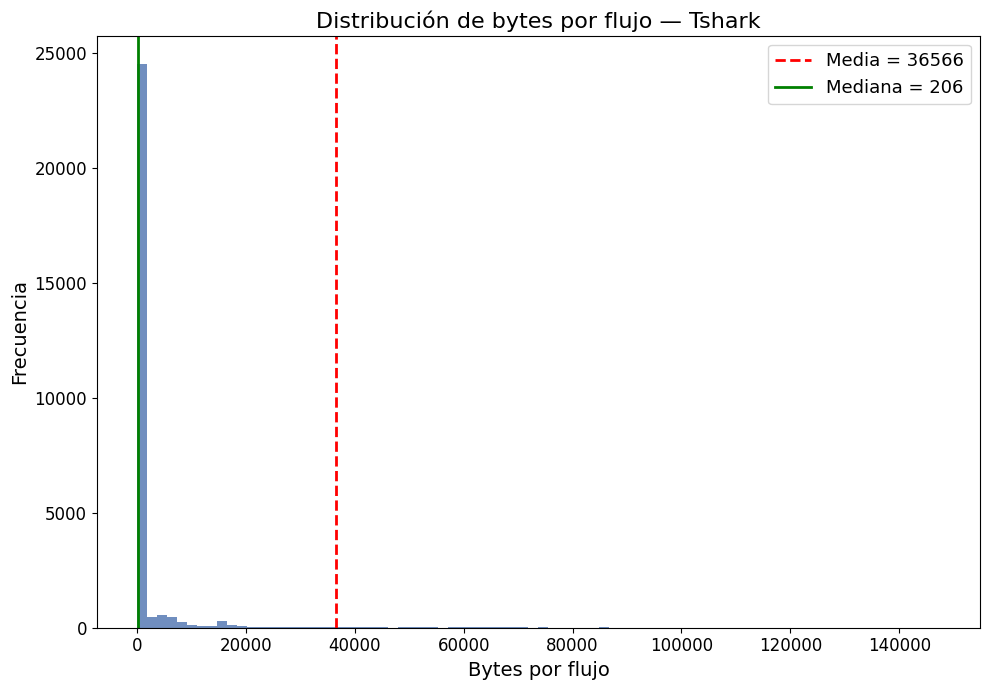

✓ Guardado: /home/miguel/Escritorio/TFM/TFM_Miguel/Figuras/distribucion_bytes_Tshark.pdf


In [16]:
# CELDA — DISTRIBUCIÓN DE BYTES POR FLUJO (4 PDFs individuales, más grandes)
import matplotlib.pyplot as plt

RUTA_FIGURAS = Path('/home/miguel/Escritorio/TFM/TFM_Miguel/Figuras')
RUTA_FIGURAS.mkdir(parents=True, exist_ok=True)

for herr, serie in datos_bytes.items():
    media = serie.mean()
    mediana = serie.median()
    limite = serie.quantile(0.99)  # recorte solo para visualizar mejor

    fig, ax = plt.subplots(figsize=(10, 7))
    ax.hist(serie[serie <= limite], bins=80, color='#4C72B0', alpha=0.8)
    ax.axvline(media, color='red', linestyle='--', linewidth=2, label=f'Media = {media:.0f}')
    ax.axvline(mediana, color='green', linestyle='-', linewidth=2, label=f'Mediana = {mediana:.0f}')
    ax.set_title(f'Distribución de bytes por flujo — {herr}', fontsize=16)
    ax.set_xlabel('Bytes por flujo', fontsize=14)
    ax.set_ylabel('Frecuencia', fontsize=14)
    ax.tick_params(labelsize=12)
    ax.legend(fontsize=13)

    plt.tight_layout()
    ruta_salida = RUTA_FIGURAS / f'distribucion_bytes_{herr}.pdf'
    plt.savefig(ruta_salida)
    plt.show()
    print(f'✓ Guardado: {ruta_salida}')

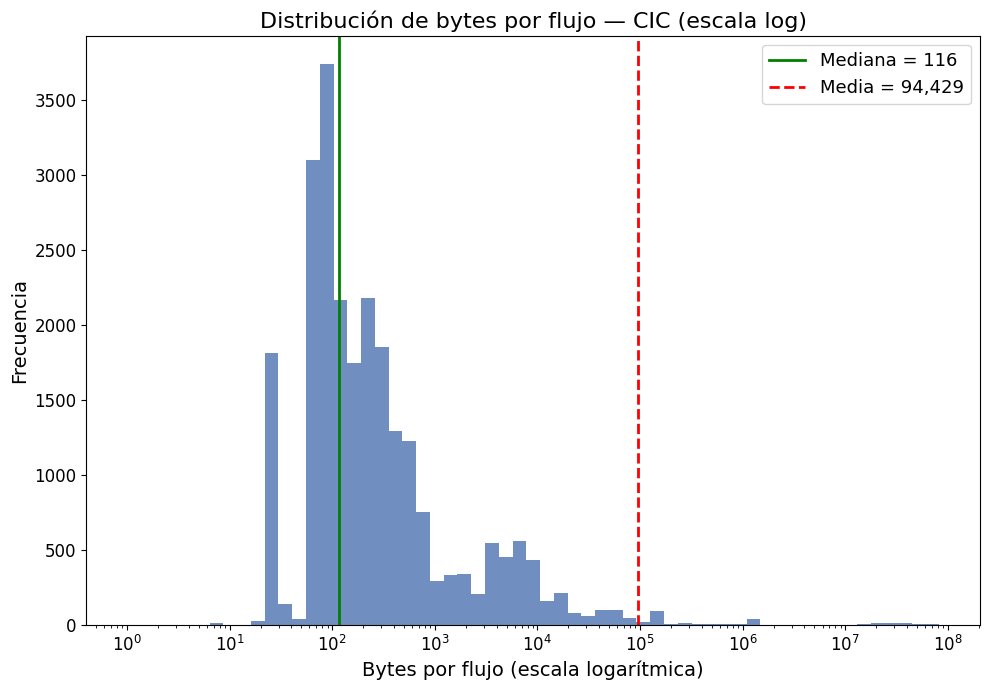

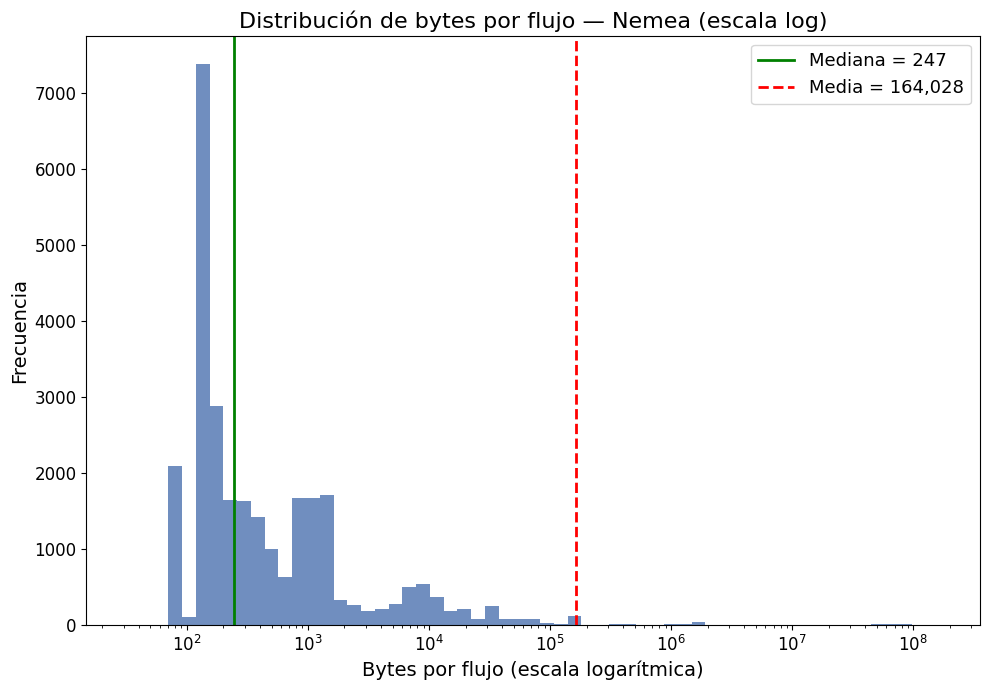

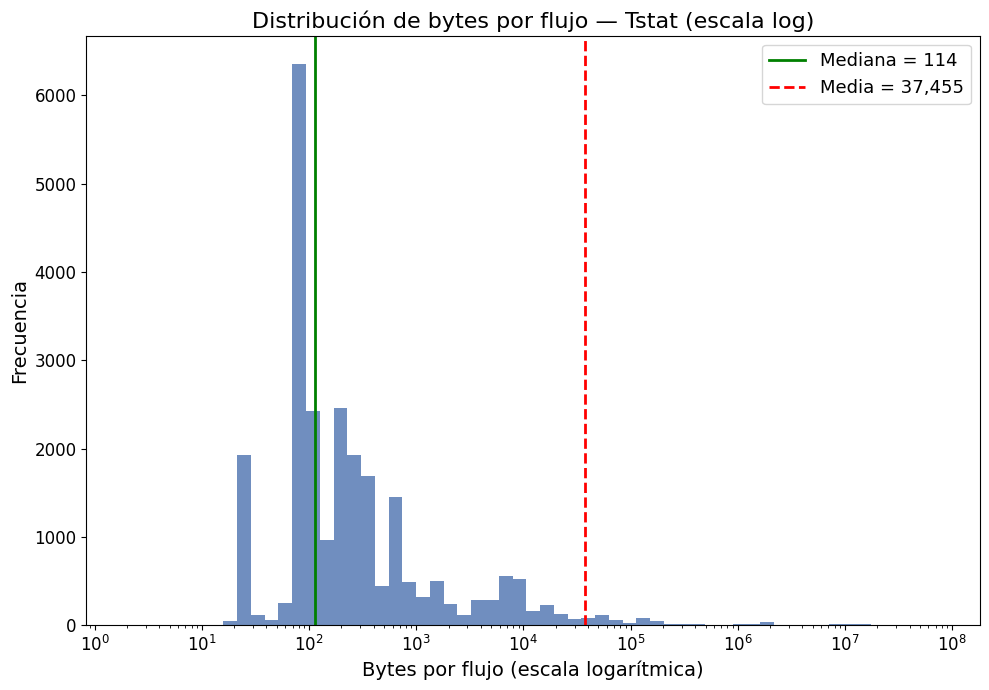

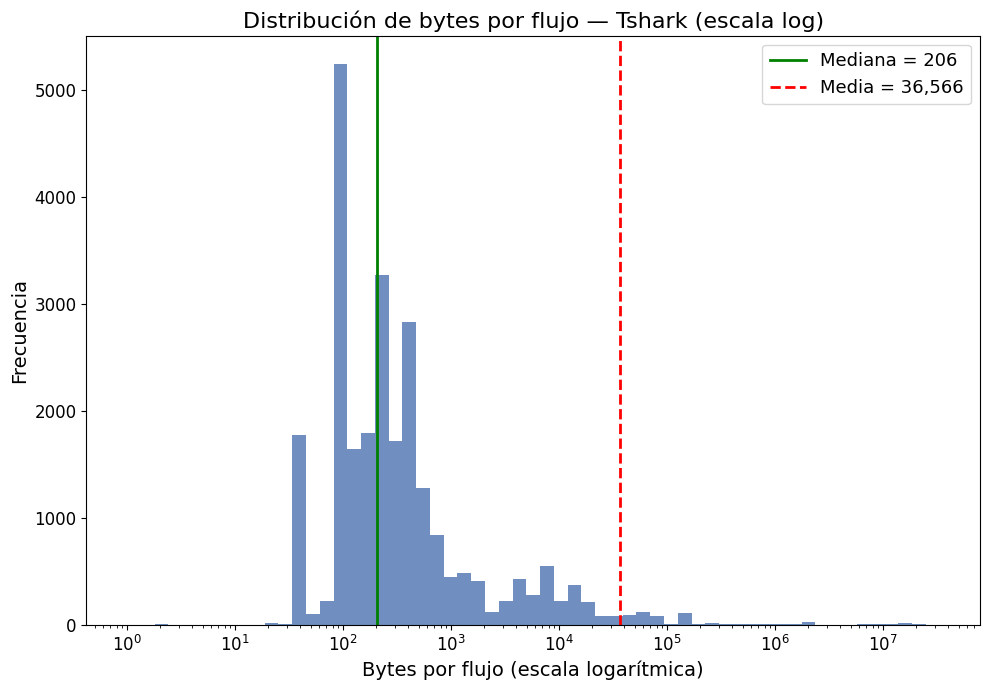

In [21]:
import matplotlib.pyplot as plt
import numpy as np

for herr, serie in datos_bytes.items():
    media = serie.mean()
    mediana = serie.median()

    fig, ax = plt.subplots(figsize=(10, 7))

    # Bins logarítmicos: necesarios para que el histograma tenga sentido en escala log
    serie_positiva = serie[serie > 0]  # evitar log(0)
    bins_log = np.logspace(np.log10(serie_positiva.min()), np.log10(serie_positiva.max()), 60)

    ax.hist(serie_positiva, bins=bins_log, color='#4C72B0', alpha=0.8)
    ax.set_xscale('log')

    ax.axvline(mediana, color='green', linestyle='-', linewidth=2, label=f'Mediana = {mediana:.0f}')
    ax.axvline(media, color='red', linestyle='--', linewidth=2, label=f'Media = {media:,.0f}')

    ax.set_title(f'Distribución de bytes por flujo — {herr} (escala log)', fontsize=16)
    ax.set_xlabel('Bytes por flujo (escala logarítmica)', fontsize=14)
    ax.set_ylabel('Frecuencia', fontsize=14)
    ax.tick_params(labelsize=12)
    ax.legend(fontsize=13)

    plt.tight_layout()
    plt.savefig(RUTA_FIGURAS / f'distribucion_bytes_{herr}_log.pdf')
    plt.show()

In [18]:
import numpy as np

for herr, serie in datos_bytes.items():
    print(f'\n=== {herr} ===')
    print(f'Media:        {serie.mean():,.0f}')
    print(f'Mediana:      {serie.median():,.0f}')
    print(f'P95:          {serie.quantile(0.95):,.0f}')
    print(f'P99:          {serie.quantile(0.99):,.0f}')
    print(f'P99.9:        {serie.quantile(0.999):,.0f}')
    print(f'P99.99:       {serie.quantile(0.9999):,.0f}')
    print(f'Máximo:       {serie.max():,.0f}')
    print(f'Nº flujos > P99: {(serie > serie.quantile(0.99)).sum()} de {len(serie)}')
    # Top 10 valores más extremos
    print(f'Top 10 valores más altos:')
    print(serie.nlargest(10).values)


=== CIC ===
Media:        94,429
Mediana:      116
P95:          8,000
P99:          85,855
P99.9:        36,277,541
P99.99:       72,773,535
Máximo:       82,539,520
Nº flujos > P99: 279 de 27848
Top 10 valores más altos:
[82539520. 76062208. 73235968. 72646656. 67500544. 66692608. 65195008.
 65145856. 59586048. 57263616.]

=== Nemea ===
Media:        164,028
Mediana:      247
P95:          12,496
P99:          154,813
P99.9:        70,434,535
P99.99:       128,279,322
Máximo:       164,113,560
Nº flujos > P99: 279 de 27848
Top 10 valores más altos:
[164113560 151369560 142489800 124380360 115703640 111825900 111567780
 108268380 104376060 102225240]

=== Tstat ===
Media:        37,455
Mediana:      114
P95:          8,457
P99:          149,677
P99.9:        13,004,956
P99.99:       23,452,774
Máximo:       75,877,867
Nº flujos > P99: 279 de 27848
Top 10 valores más altos:
[75877867 27229696 24182784 23252480 22427136 21854720 20038144 20011520
 19931648 19548672]

=== Tshark ===
Med

In [19]:
# Diagnóstico: ¿en qué clase caen los flujos más extremos de cada herramienta?
for herramienta, cols in cols_bytes.items():
    filas = []
    for clase in CLASES:
        ruta = RUTA_BASE / clase / f'{herramienta}.csv'
        if ruta.exists():
            df = pd.read_csv(ruta, usecols=cols, low_memory=False)
            df['bytes_total'] = df[cols[0]] + df[cols[1]]
            df['clase'] = clase
            filas.append(df[['bytes_total', 'clase']])
    total = pd.concat(filas)
    print(f'\n=== {herramienta} — top 10 flujos más grandes, por clase ===')
    print(total.nlargest(10, 'bytes_total'))


=== CIC — top 10 flujos más grandes, por clase ===
      bytes_total  clase
3392   82539520.0  Mirai
303    76062208.0  Mirai
898    73235968.0  Mirai
564    72646656.0  Mirai
359    67500544.0  Mirai
1860   66692608.0  Mirai
2556   65195008.0  Mirai
639    65145856.0  Mirai
2413   59586048.0  Mirai
842    57263616.0  Mirai

=== Nemea — top 10 flujos más grandes, por clase ===
      bytes_total  clase
1336    164113560  Mirai
2436    151369560  Mirai
3255    142489800  Mirai
801     124380360  Mirai
2411    115703640  Mirai
936     111825900  Mirai
3407    111567780  Mirai
73      108268380  Mirai
1245    104376060  Mirai
2968    102225240  Mirai

=== Tstat — top 10 flujos más grandes, por clase ===
      bytes_total     clase
3096     75877867  Spoofing
2913     27229696     Mirai
2453     24182784     Mirai
1524     23252480     Mirai
1143     22427136     Mirai
823      21854720     Mirai
1217     20038144     Mirai
2169     20011520     Mirai
1720     19931648     Mirai
1149     1